# Dataset Description
## Top 3 deaths among young men

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

# Code
## Imports

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.ticker as mtick

BASE_DIR = Path.cwd().parent.parent

## Load data

In [43]:
path = "./data/departamento_muerte.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8")
logo = plt.imread(logo_path)

## Clean data

In [44]:
columns = df.columns[
    ~(df.columns.str.contains("Indeterminado")) & 
    ~(df.columns.str.contains("otal")) & 
    ~(df.columns.str.contains("desconocida"))
]

df_f = df.loc[:, columns]

df_f = df_f[
    (df_f["Fecha"].eq(2025)) &
    (df_f["departamento"].eq("Total Nacional"))
]

df_f = df_f.drop(columns=["Fecha", "departamento"])

columns_male = df_f.columns.str.contains("Hombre|causa", regex=True)

male = df_f.loc[:, columns_male]

age_groups = { 
    "15-34": ["De 15 a 19 años", "De 20 a 24 años", "De 25 a 29 años", "De 30 a 34 años"],
}

def group_by_age_cause(df_gender, suffix, groups):
    rows = []
    for label, prefixes in groups.items():
        cols = [f"{p}_{suffix}" for p in prefixes]
        available = [c for c in cols if c in df_gender.columns]
        if available:
            deaths = df_gender[available].sum(axis=1)
            top3 = deaths.nlargest(3)
            for idx, value in top3.items():
                rows.append({
                    "cause": df_gender["causa"].loc[idx],
                    "deaths": value
                })
    return pd.DataFrame(rows)

male_grouped = group_by_age_cause(male, "Hombres", age_groups)

cause_translations = {
    "090 Accidentes de transporte de motor y secuelas": "Motor vehicle accidents",
    "100 Lesiones autoinfligidas intencionalmente (suicidios) y secuelas": "Suicides",
    "101 Agresiones (homicidios) y secuelas": "Homicides",
}

male_grouped["cause"] = male_grouped["cause"].map(cause_translations)
male_grouped.sort_values(by="deaths", ascending=True, inplace=True)

## Plot

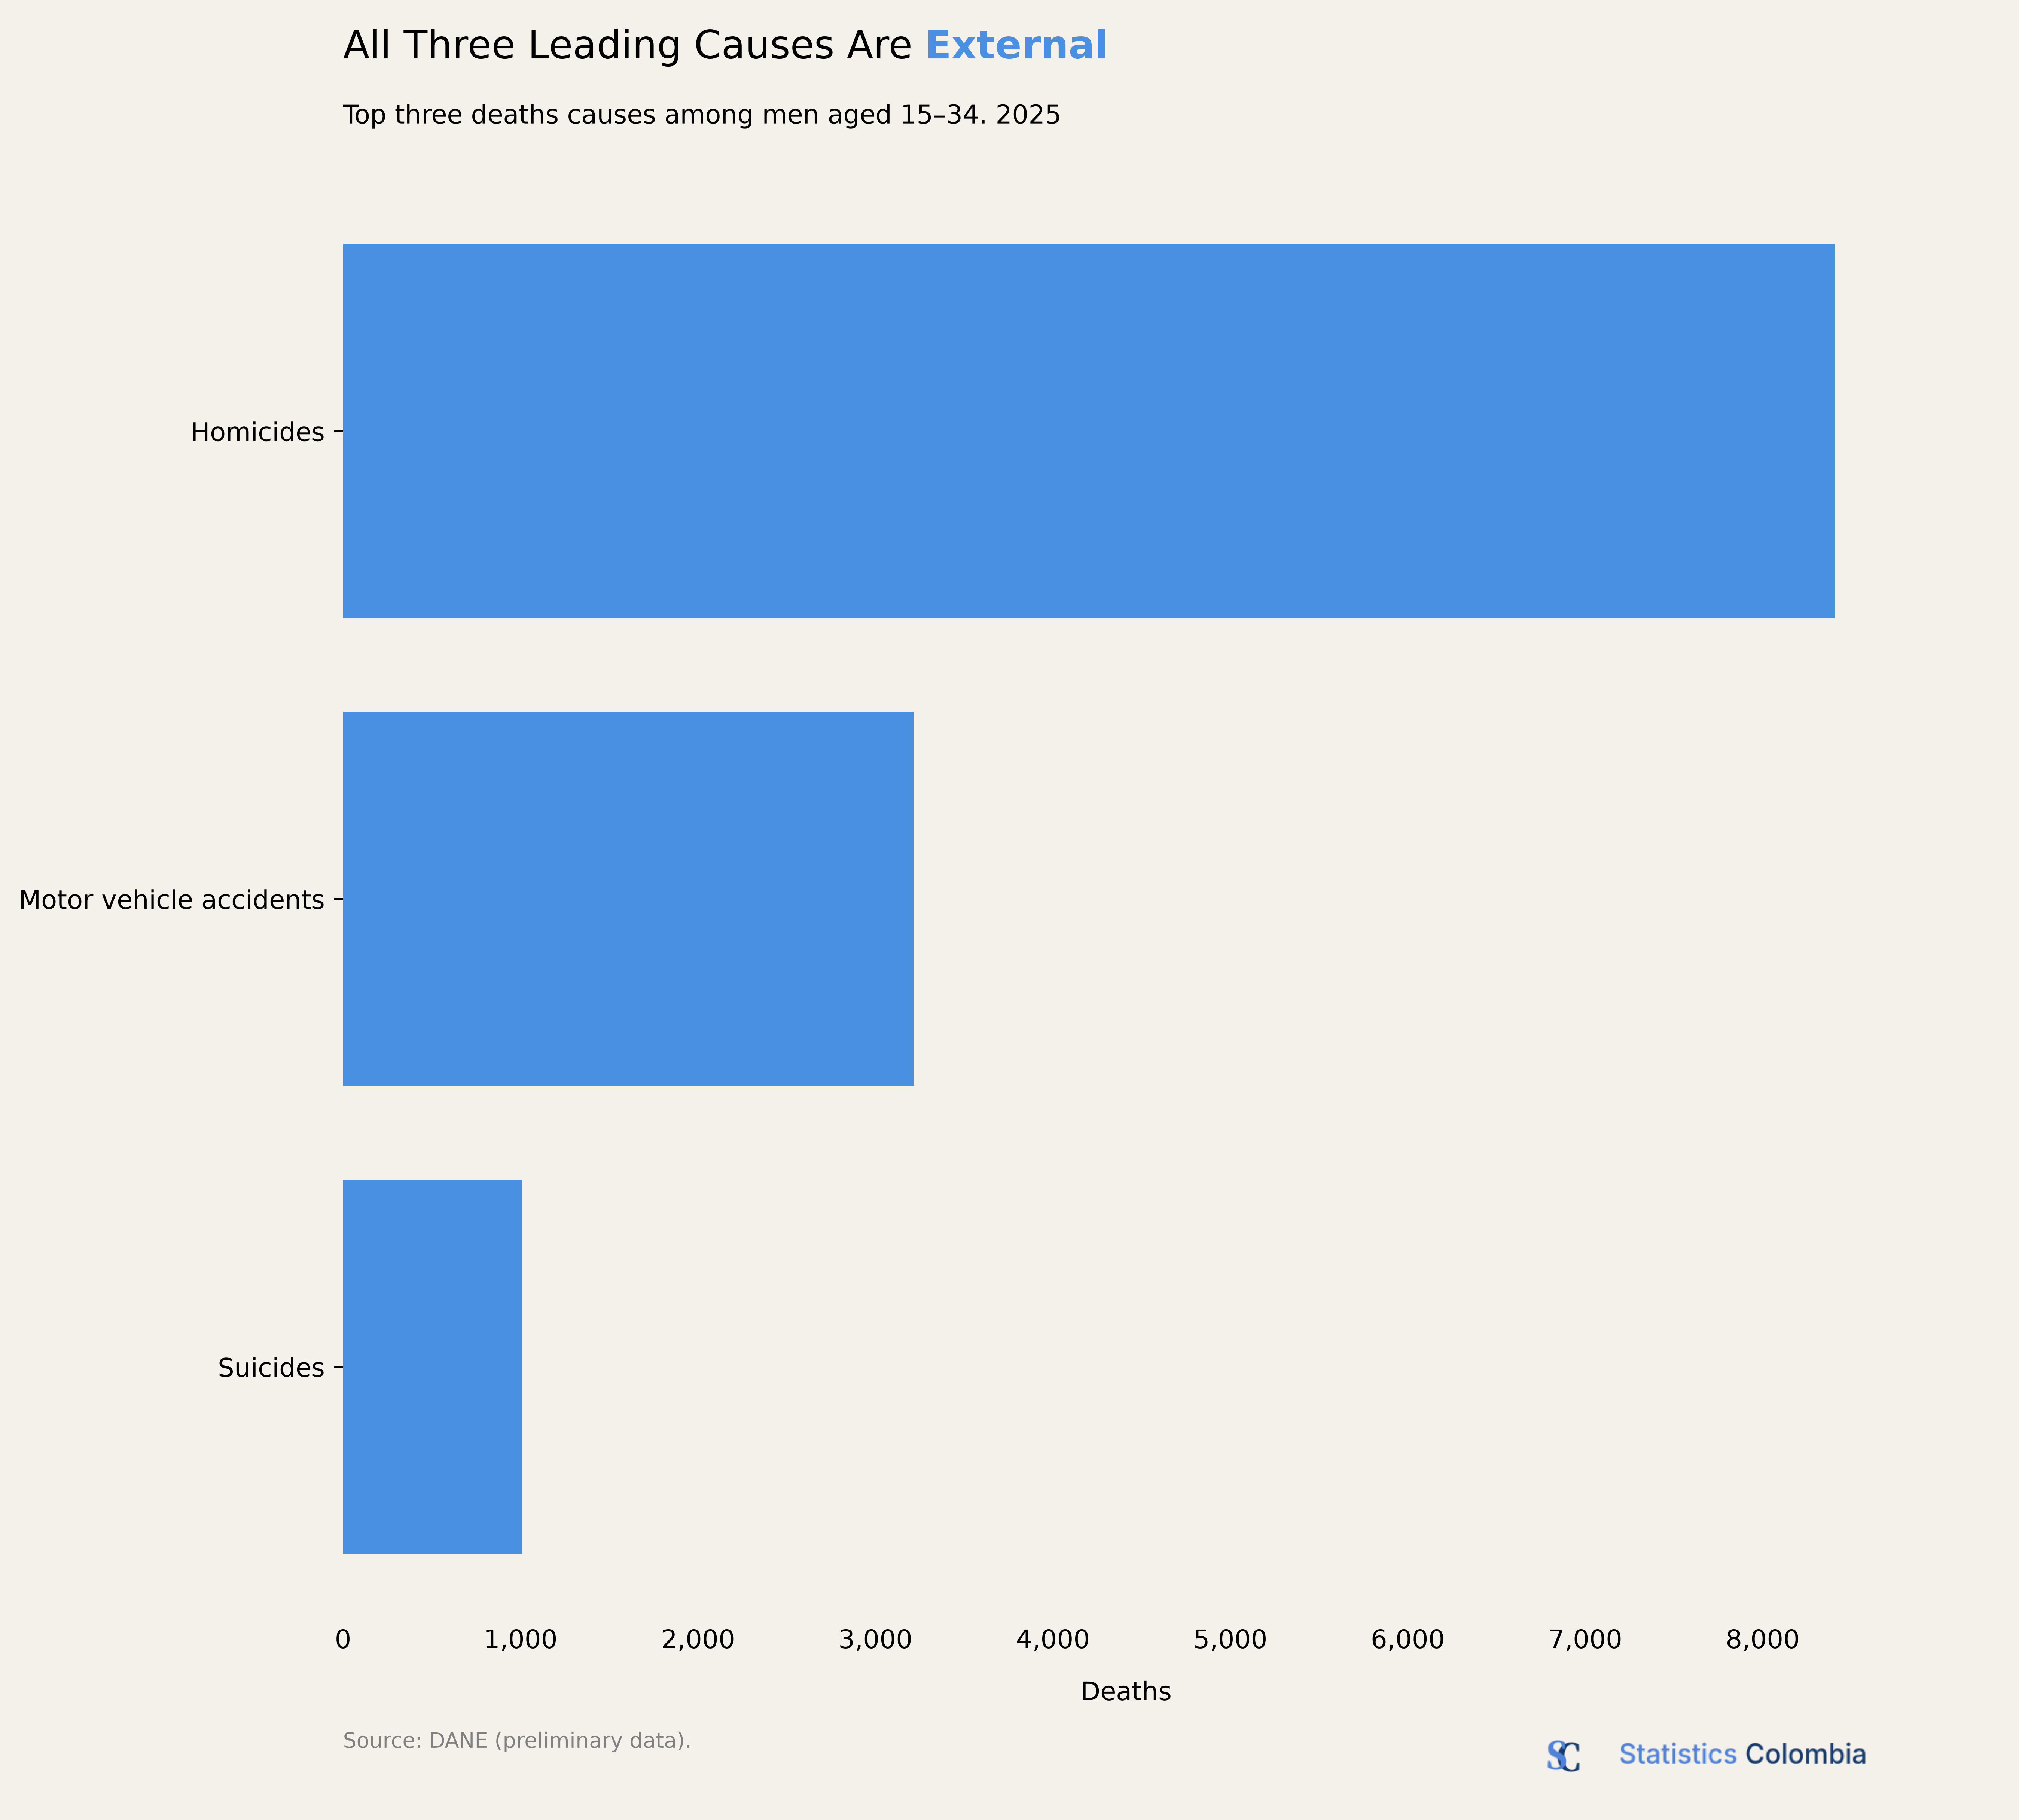

In [45]:
blue = "#4a90e2"
background = "#F4F1EA"

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.barh(male_grouped["cause"], male_grouped["deaths"], color=blue)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

plt.tick_params(axis="x", length=0)

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xlabel("Deaths", labelpad=10, fontsize=10)

fig_text(
    x=0.125, y=0.96,
    s="All Three Leading Causes Are <External>",
    highlight_textprops=[{"color": blue, "weight": "bold"}],
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="Top three deaths causes among men aged 15–34. 2025"
)

fig_text(
    0.125, 0.05, 
    "Source: DANE (preliminary data).", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.85, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()